# Setting libraries and functions

In [35]:
%matplotlib widget
import pybt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')



plt.ion()


In [36]:
plt.close('all')

In [37]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

import septa

In [38]:
p = 400.0  # beam momentum (GeV/c)
momentum = p  # beam momentum (GeV/c)
Brho = p * 3.3356  # beam rigidity ???

N_EX = 10e-6
N_EY = 5e-6
DPP = 1e-4


In [39]:
""" 
class SeptumInteraction:
    def __init__(self, blade_position: float = 68e-3, thickness: float = 0.3e-3, kick: float = 1e-3, angle: float = -1.5, width: float = 0, aperture: float = 1e-2) -> None:
        self.blade_position = blade_position
        self.thickness = thickness
        self.kick = kick
        self.angle = angle  # Not used currently
        self.width = width  # Not used currently
        self.aperture = aperture
        pass

    def interact(self, particles: xp.Particles) -> t.Optional[t.Dict]:
        n_part = particles._num_active_particles

        # Apply kick for particles inside the aperture
        if self.kick != 0:
            mask_kick = (particles.x[:n_part] > (self.blade_position + self.thickness)) & \
                        (particles.x[:n_part] < (self.blade_position + self.thickness + self.aperture)) & \
                        (particles.state[:n_part] == 1)
            particles.px[:n_part] += np.where(mask_kick, self.kick, 0)

        # Mark particles as lost if they hit the blade or are beyond the aperture
        mask_eliminate = (
            ((particles.x[:n_part] >= self.blade_position) & 
             (particles.x[:n_part] < (self.blade_position + self.thickness))) |  # Hitting the blade
            (particles.x[:n_part] > (self.blade_position + self.thickness + self.aperture))  # Beyond aperture
        ) & (particles.state[:n_part] == 1)

        particles.state[:n_part] = np.where(mask_eliminate, -1, particles.state[:n_part])

        # No action for particles below the blade
        # Particles below self.blade_position remain unaffected.

        return None
        
"""


' \nclass SeptumInteraction:\n    def __init__(self, blade_position: float = 68e-3, thickness: float = 0.3e-3, kick: float = 1e-3, angle: float = -1.5, width: float = 0, aperture: float = 1e-2) -> None:\n        self.blade_position = blade_position\n        self.thickness = thickness\n        self.kick = kick\n        self.angle = angle  # Not used currently\n        self.width = width  # Not used currently\n        self.aperture = aperture\n        pass\n\n    def interact(self, particles: xp.Particles) -> t.Optional[t.Dict]:\n        n_part = particles._num_active_particles\n\n        # Apply kick for particles inside the aperture\n        if self.kick != 0:\n            mask_kick = (particles.x[:n_part] > (self.blade_position + self.thickness)) &                         (particles.x[:n_part] < (self.blade_position + self.thickness + self.aperture)) &                         (particles.state[:n_part] == 1)\n            particles.px[:n_part] += np.where(mask_kick, self.kick, 0)\n\n   

In [40]:
class SeptumInteraction:
    def __init__(self, blade_position: float = 68e-3, thickness:float = 0.3e-3, kick:float = 1e-3) -> None:
        self.blade_position = blade_position
        self.thickness = thickness
        self.kick = kick
        pass

    def interact(self, particles: xp.Particles) -> t.Optional[t.Dict]:
        n_part = particles._num_active_particles

        # lose the particles on the blade
        particles.state[:n_part] = np.where((particles.x[:n_part]>self.blade_position) & (particles.x[:n_part]<(self.blade_position+self.thickness)) & (particles.state[:n_part]==1), -1, 1)

        # kick the particles beyond the blade
        if self.kick != 0:
            particles.px[:n_part] +=  np.where((particles.x[:n_part] > (self.blade_position+self.thickness)) & (particles.state[:n_part]==1), 1, 0) * self.kick

        return None


In [41]:
def install_iterated_ZSsepta(line, install_zs=True, subdivision_number = 50):
    septa_names_with_apertures = []

    if install_zs:
        septum_names = septa.septum_namesZS
        subdivision_number = subdivision_number  
        width = septa.widthZSelements  # Length of the entire element in s
        heightZS = septa.thicknessZSelements
        blade_positionsZS = septa.blade_positionsZS
        aperture = septa.apertureZS
        
        # Installing monitors to measure the particles positions at their passage
        monitors = []
        
        for septum_name in septum_names:  # Cycle for every element
            n = septum_names.index(septum_name)
            # Assigning thickness based on the septum name
            if septum_name in ["zs.21633", "zs.21639"]:
                thickness = 0.6e-4
            else:
                thickness = 1e-4
            
            for i in range(subdivision_number):  # Cycle for subdivision
                # Scalo verso il basso la blade_position per ogni suddivisione
                blade_position = blade_positionsZS[n] - i * heightZS / subdivision_number
                index_of_suddivision = str(i)
                
                # Calculate the position along the line (s)
                at_s_position = line.get_s_position(septum_name) + i * (width / subdivision_number)
            
                # Inserting the anode
                zs = xt.BeamInteraction(
                    length = 0.0,
                    interaction_process = SeptumInteraction(
                        blade_position = blade_position,
                        thickness = thickness,
                        kick = septa.kickZS / (subdivision_number),
                        angle = -1.5, #the angle is actually not used in this model so it can be removed
                        width = width / subdivision_number,   #This is the length in s of the element
                        aperture = aperture
                    ),
                )
                line.insert_element(
                    name = septum_name + "_" + index_of_suddivision + ".sep",
                    element = zs,
                    at_s = at_s_position  
                )
                septa_names_with_apertures.append(septum_name + "_" + index_of_suddivision + ".sep")
                
                
                # Installing monitors for every sliced element
                monitor = xt.BeamSizeMonitor(stop_at_turn=1)
                line.insert_element(
                    name = septum_name + "_" + index_of_suddivision +".monitor",
                    element = monitor,
                    at_s = at_s_position  # inserting the monitors at the desired position
                )
                monitors.append(monitor) #CHECK ONE_TURN_MONITOR IN TRACKING
                
                            

        #Installing monitor at the ZS end to obtatin the beam's envelop outside the ZS
        last_septum_name = septum_names[-1]
        last_s_position = line.get_s_position(last_septum_name) + width # Position after the last septum
        exit_monitor = xt.BeamSizeMonitor(stop_at_turn=1)
        
        line.insert_element(
            name = "ZS_exit.monitor",
            element = exit_monitor,
            at_s = last_s_position  # Insert monitor after the last septum element
        )
        
        #Installing monitor outside the MST to obtatin the beam's envelop outside the MST
        outside_monitors_numberZS = 8
        for i in range(outside_monitors_numberZS):
            outside_monitor_number = str(i)
            last_septum_name = septum_names[-1]
            last_s_position = line.get_s_position(last_septum_name) + width * i * 1.2  # Position after the last septum
            outside_monitor = xt.BeamSizeMonitor(stop_at_turn = 1)
            
            line.insert_element(
                name = "ZS_outside_" + outside_monitor_number + ".monitor",
                element = outside_monitor,
                at_s = last_s_position  # Insert monitor after the last septum element for i times
            )
            monitors.append(outside_monitor) 
        
        #Installing monitor at the entrance
        first_s_position = line.get_s_position('zs.21633_0.monitor') - width/subdivision_number * 0.99 # Position after the last septum
        monitor = xt.BeamSizeMonitor(stop_at_turn=1)
        
        line.insert_element(
            name = "ZSEntry.monitor",
            element = monitor,
            at_s = first_s_position  # Insert monitor after the last septum element
        )        
                
    return septa_names_with_apertures


In [42]:
# install the 5 zs
def install_septa(line, install_zs=True, septum_aperture_size=68e-3):
    septa_names_with_apertures = []

    if install_zs:
        septum_names = ["zs.21633", "zs.21639", "zs.21655", "zs.21671", "zs.21676"]
        
        for septum_name in septum_names:
            zs = xt.BeamInteraction(
                length=0.0,
                interaction_process=SeptumInteraction(
                    blade_position=septum_aperture_size, thickness=0.3e-3, kick=0.440e-3 / 5
                ),
            )
            line.insert_element(septum_name + ".sep", zs, index=septum_name)
            septa_names_with_apertures.append(septum_name + ".sep")

        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=5.2e-3, kick=0
            ),
        )
        line.insert_element("tpst.21760_entry" + ".sep", zs, index="tpst.21760_entry")
        septa_names_with_apertures.append("tpst.21760_entry" + ".sep")


    for mst in ["mst.21774", "mst.21779", "mst.21794"]:
        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=5.2e-3, kick=1.69520713e-3 / 3
            ),
        )
        line.insert_element(mst + ".sep", zs, index=mst)
        septa_names_with_apertures.append(mst + ".sep")

    for mse in ["mse.21832", "mse.21837", "mse.21852", "mse.21857", "mse.21872"]:
        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=20e-3, kick=9.74519477e-3 / 5
            ),
        )
        line.insert_element(mse + ".sep", zs, index=mse)
        septa_names_with_apertures.append(mse + ".sep")

    septum = xt.LimitRect(min_x=-1.0, max_x=septum_aperture_size, min_y=-1.0, max_y=1.0)


    line.insert_element(
        name="tt20.extraction",
        element=xt.LimitRect(min_x=-1.0, max_x=70e-3, min_y=-1.0, max_y=1.0),
        index="ap.do.mse21872",
    )
    return septa_names_with_apertures


In [43]:
def draw_synoptic(ax, line, line_df):
    
    compound_names = line_df["name"].unique()
    for compound_name in compound_names:
        compound_df = line_df[line_df["name"] == compound_name]
        if compound_df["element_type"].isin(["Quadrupole"]).any():
            k1 = (
                compound_df[compound_df["element_type"] == "Quadrupole"]["element"]
                .squeeze()
                .k1
            )
            s1, s2 = compound_df["s"].min(), compound_df["s"].max()
            _ = ax.add_patch(
                mpl.patches.Rectangle(
                    (s1, 0), s2 - s1, np.sign(k1), facecolor="k", edgecolor="k"
                )
            )
        elif compound_df["element_type"].isin(["Sextupole", 'Bend', 'Multipole']).any():
            s1, s2 = compound_df["s"].min(), compound_df["s"].max()
            _ = ax.add_patch(
                mpl.patches.Rectangle(
                    (s1, -1), s2 - s1, 2, facecolor="k", edgecolor="k"
                )
            )

def plot_twiss(fig, twiss, line):

    gs = mpl.gridspec.GridSpec(3, 1, height_ratios=[1, 4, 4])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2], sharex=ax1)     #UNUSED, IMPLEMENT TO HAVE THE VISUAL REPRESENTATION OF THE ENVELOPE THOUGH THE LATTICE

    plt.setp(ax2.get_xticklabels(), visible=False)

    # top plot is synoptic
    ax1.axis('off')
    ax1.set_ylim(-1.2, 1)
    ax1.plot([0, twiss['s'].max()], [0, 0], 'k-')


    #2nd plot is beta functions
    ax2.set_ylabel(r'Twiss (m)')
    ax2.plot(twiss['s'], twiss['betx'], 'r-', label=r'$\beta_x$')
    ax2.plot(twiss['s'], twiss['bety'], 'b-', label=r'$\beta_y$')
    ax2.plot(twiss['s'], twiss['dx']*10, 'g-', label=r'$D_x x10$')
    ax2.set_xlim(twiss['s'][0], twiss['s'][-1])
    ax2.legend(loc='upper right')

    line_df = line.to_pandas()
    line_df = line_df[(line_df['s'] >= twiss.s[0]) & (line_df['s'] <= twiss.s[-1])]

    draw_synoptic(ax1, line, line_df)
    
    axnames = ax1.twiny()
    axnames.spines['top'].set_visible(False)
    axnames.spines['left'].set_visible(False)
    axnames.spines['right'].set_visible(False)
    ax1.get_shared_x_axes()._grouper.join(ax1, axnames)
    
    ticks, ticks_labels = list(), list()
    
    for keyword in ['Quadrupole', 'Sextupole', 'Bend', 'Multipole']:
        sub_line = line_df[line_df['element_type'] == keyword]
        ticks += list(sub_line['s'])
        ticks_labels += list(sub_line['name'])

    axnames.set_xticks(ticks)
    axnames.set_xticklabels(ticks_labels, rotation=60)




# with ZS

In [44]:
line = xt.Line.from_json("./sps_with_extraction_sliced_quads.json")
septa_names_with_apertures = install_septa(line)
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)

line.cycle("bpcn.20902_entry", inplace=True)

tw = line.twiss()
print(tw.qx, tw.qy, tw.dqx, tw.dqy)

n_part = 300
zeta = 0.0
x_norm, px_norm = xp.generate_2D_gaussian(num_particles=n_part)
y_norm, py_norm = xp.generate_2D_gaussian(num_particles=n_part)
dpp = np.random.rand(n_part) * DPP


particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)


particles_init = particles.copy()
tw_lss2 = tw.rows['bpcn.20902_entry':'lsf.22005_entry']

Loading line from dict:   0%|          | 0/9960 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/9975 [00:00<?, ?it/s]

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


Ignoring collective elements in particles generation.


26.666467651236395 26.580038000864008 -35.40212065011872 14.473207377996289


In [45]:
# monitor particles at all unique positions between mba.21390_exit and qda.21910_exit
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
tw_lss2_df = tw_lss2_df.loc['mbb.20950_exit':'qda.21910_exit']  
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

line.discard_tracker()

def set_monitor(row):
    monitor = xt.LastTurnsMonitor(n_last_turns=6, num_particles=particles._capacity, every_n_turns=1)
    line.insert_element(name=row.name+'_monitor', element=monitor, index=row.name)
    return monitor
tw_lss2_df['monitors'] = tw_lss2_df.apply(set_monitor, axis=1)
tw_lss2_df['i_monitor'] = np.arange(len(tw_lss2_df))    


In [46]:
bg = line.particle_ref._gamma0[0]*line.particle_ref._beta0[0]  #this line is calculating the relativistic quantity Beta Gamma for the reference particle in the line
sigma_x = lambda bet, d, n_sigma=1, bg=bg, dpp=DPP, eps=N_EX: np.sqrt(bet*eps/bg + (d*dpp)**2)*n_sigma  #computing the the BEAM SIZE at a given location

#place the element apertures relative to the circulating beam
distance_to_beam_at_first_zs_sigma = (line['zs.21633.sep'].interaction_process.blade_position - tw_lss2['x', 'zs.21633.sep'])/sigma_x(tw_lss2['betx', 'zs.21633.sep'], tw_lss2['dx', 'zs.21633.sep'])


# placing the zs at the same distance from the circulating beam, the magnetic ones further
for septum_name in septa_names_with_apertures:
    if 'mst' in septum_name:
        sigma_margin = 2
    elif 'mse' in septum_name:
        sigma_margin = 5
    else:
        sigma_margin = 0

    distance_to_beam = (distance_to_beam_at_first_zs_sigma + sigma_margin) *sigma_x(tw_lss2['betx', septum_name], tw_lss2['dx', septum_name])
    line[septum_name].interaction_process.blade_position = tw_lss2['x', septum_name] + distance_to_beam

In [47]:
num_turns = 300
line.discard_tracker()
#line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto')) #Not working on MacOS
line.build_tracker(_context=xo.ContextCpu()) 


particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    # turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
line.time_last_track

29.536492243001703

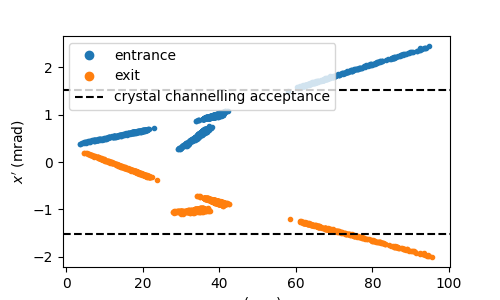

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(5,3))



for i, (target_s, label) in enumerate(zip([225.548 , 229.339],['entrance', 'exit'])):
    elem = tw_lss2_df.loc[(tw_lss2_df['s'] - target_s).abs().idxmin()]
    ax.plot(elem['monitors'].x*1e3, elem['monitors'].px*1e3, '.', color=plt.cm.tab10(i))
    ax.plot([], [], 'o', color=plt.cm.tab10(i), label=label)

ax.plot([], [], 'k--', label='crystal channelling acceptance')

ax.legend()
ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

ax.axhline(-1.5-10e-3, color='k', ls='--')
ax.axhline(+1.5+10e-3, color='k', ls='--')


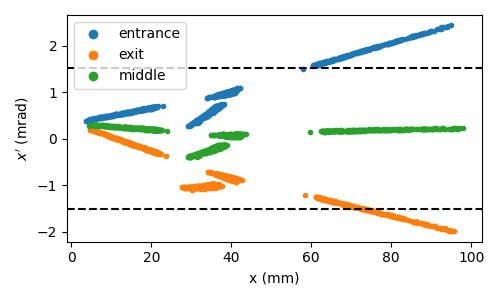

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(5,3), tight_layout=True)



for i, (target_s, label) in enumerate(zip([225.548 , 229.339, 227.822],['entrance', 'exit', 'middle'])):
    elem = tw_lss2_df.loc[(tw_lss2_df['s'] - target_s).abs().idxmin()]
    ax.plot(elem['monitors'].x*1e3, elem['monitors'].px*1e3, '.', color=plt.cm.tab10(i))
    ax.plot([], [], 'o', color=plt.cm.tab10(i), label=label)

# ax.legend()
ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

ax.legend()

ax.axhline(-1.5-10e-3, color='k', ls='--')
ax.axhline(+1.5+10e-3, color='k', ls='--')
ax.plot([], [], 'k--', label='crystal channelling acceptance')





In [50]:
for angle in [190, 205, 220]:
    ax.fill_between([60, 100], (angle-10)*1e-3, (angle+10)*1e-3, color='k', alpha=0.2)


## tracking around the septa

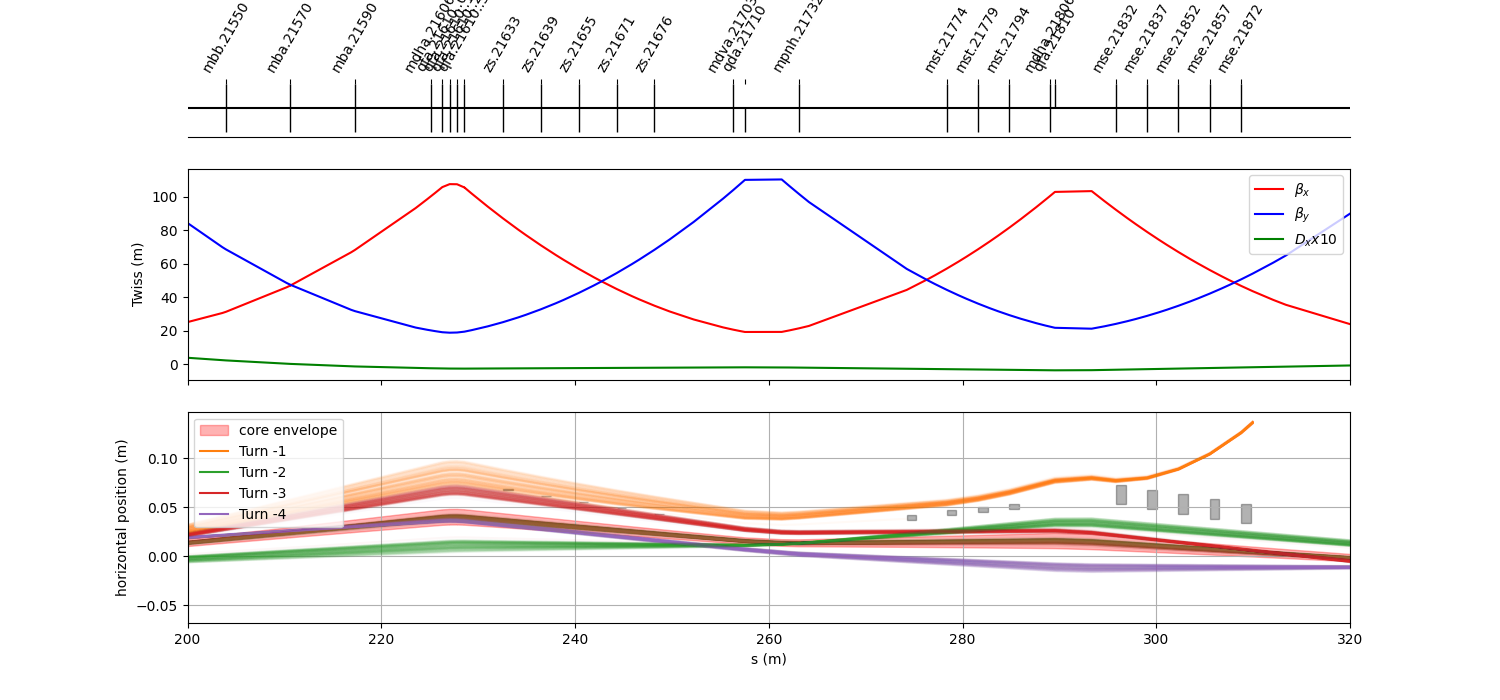

In [51]:
fig = plt.figure(figsize=(15,7))

plot_twiss(fig, tw_lss2, line)
fig.axes[2].grid(True)
fig.axes[2].set_xlim(200, 320)
fig.axes[2].set_xlabel('s (m)')
fig.axes[2].set_ylabel('horizontal position (m)')



# ploting of the envelope
fig.axes[2].plot(tw_lss2.s, tw_lss2.x, 'r-')
fig.axes[2].fill_between(tw_lss2.s, tw_lss2.x-sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), tw_lss2.x+sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), color='r', alpha=0.3, label='core envelope')

for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    fig.axes[2].add_patch(mpl.patches.Rectangle((s, x), 1, thickness, color='k', alpha=0.3))
    
    
### PLOTTING TRAJECTORIES     
ax = fig.axes[2]
alpha = 10/particles._capacity
plot_only_lost = False
num_turns = 4

all_trajs = tw_lss2_df.apply(lambda row: row['monitors'].x, axis=1)
all_trajs = np.stack(all_trajs.values)

for ipart in range(particles._capacity):
    state = particles.state[ipart]
    if plot_only_lost and state > 0:
        print(f"Skipping particle {ipart} ")
        continue

    particle_id = particles.particle_id[ipart]
    el_lost = particles.at_element[ipart]
    traj = all_trajs[:, particle_id, :]
    # print(f"Particle {ipart} lost at {el_lost} with state {state} and id {particle_id} ")

    if state <= 0:
        # need to recontruct the turns since the particle was last
        s_lost = line.get_table()['s', line.element_names[el_lost]]
        row_lost = tw_lss2_df[abs(tw_lss2_df['s'] - s_lost) < 20e-3].squeeze()
        i_lost = row_lost['i_monitor']+1

        traj_corr = np.nan * np.ones_like(traj)
        traj_corr[:i_lost, -1] = traj[:i_lost, -1]
        for iturn in range(2, num_turns+1):
            traj_corr[:, -iturn] = np.hstack([traj[:i_lost, -iturn-1], traj[i_lost:, -iturn]])
        traj = traj_corr

    for iturn in range(1, num_turns+1):
        ax.plot(tw_lss2_df['s'], traj[:, -iturn], color=plt.cm.tab10(iturn), alpha=alpha, ls='-') 
for iturn in range(1, num_turns+1):
    ax.plot([], [], color=plt.cm.tab10(iturn), label=f"Turn -{iturn}")
ax.legend(loc = 'upper left')

In [52]:
# ax2.plot(tw_lss2_df['s'], (tw_lss2_df['mux']-tw_lss2_df.loc['tpst.21760_entry.sep']['mux'])*360, 'k--', label=r'$\Delta \mu_x$')
# ax2.legend

# ax2.axhline(0, color='k', ls='--', alpha=0.3)
# ax2.axhline(-90, color='k', ls='--', alpha=0.3)
# ax2.axhline(-270, color='k', ls='--', alpha=0.3)

tpst_row = tw_lss2_df.loc['tpst.21760_entry.sep']
# for loc in ['tecs.21602_entry', 'mdh.21207_exit']:
#     row = tw_lss2_df.loc[loc]
#     dphi = (row['mux']-tpst_row['mux'])
#     print(f"{loc:30s} {dphi*360:6.2f}deg and sin is {np.sin(dphi*np.pi):6.2f}")



# replacing ZS by crystal

## Cration of the line

In [65]:
n_part = 100

x_norm, px_norm = xp.generate_2D_gaussian(num_particles=n_part)
y_norm, py_norm = xp.generate_2D_gaussian(num_particles=n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * DPP


In [66]:
# loading optics but thining the 2 quads in LSS2
line : xt.Line = xt.Line.from_json("sps_with_extraction_sliced_quads.json")
septa_names_with_apertures = install_septa(line, install_zs=False)
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)

line.cycle("bpcn.20902_entry", inplace=True)

""" 
line.slice_thick_elements(
    slicing_strategies=[
        xt.Strategy(slicing=None),
        xt.Strategy(slicing=xt.Uniform(4), name='qf.21210'),
        xt.Strategy(slicing=xt.Uniform(4), name='qfa.21610'),
])


class EverestCrystal(BaseCollimator):
    _xofields = { **BaseCollimator._xofields,
        'align_angle':        xo.Float64,  #  = - sqrt(eps/beta)*alpha*nsigma
        '_bending_radius':    xo.Float64,
        '_bending_angle':     xo.Float64,
        '_critical_angle':    xo.Float64,
        'xdim':               xo.Float64,
        'ydim':               xo.Float64,
        'thick':              xo.Float64,
        'miscut':             xo.Float64,
        '_orient':            xo.Int8,
        '_material':          CrystalMaterial,
        'rutherford_rng':     xt.RandomRutherford,
        '_tracking':          xo.Int8
    }
    
    crystal = xc.BaseCollimator(
    material=xc.materials.SiliconCrystal,
    active_length=4e-3,
    bending_angle=10,
    xdim=100e-3,
    ydim=50e-3,
    side="left",
    lattice="strip",
    jaw_L=72e-3,
    align_angle=200e-6,
)
"""

tw_init = line.twiss()
#print(tw_init)



Loading line from dict:   0%|          | 0/9960 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/9969 [00:00<?, ?it/s]

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


## Crystal definition

In [67]:
crystal = xc.EverestCrystal(
    length=4e-3, 
    material=xc.materials.SiliconCrystal, 
    bending_angle = 40e-5 ,
    side="left",
    lattice="strip",
    jaw = 72e-3,
    tilt = 200e-6,
    width = 100e-3,
    height = 50e-3
    )

 
crystal2 = xc.EverestCrystal(
    material=xc.materials.SiliconCrystal,
    length=4e-3,
    bending_angle=40e-5,
    side="left",
    lattice="strip",
    jaw = 72e-3,
    tilt = 220e-6,
    width = 100e-3,
    height = 50e-3
    )

crystal3 = xc.EverestCrystal(
    material=xc.materials.SiliconCrystal,
    length=4e-3,
    bending_angle=40e-5,
    side="left",
    lattice="strip",
    jaw = 72e-3,
    tilt = 200e-6,
    width = 100e-3,
    height = 50e-3
    )

crystal_dump = xt.LimitRect(min_x=-1., max_x=72e-3, min_y=-1., max_y=1.)

line.discard_tracker()

line.insert_element("extraction.crystal.up", xt.Marker(), at_s=line.get_table()['s', 'qfa.21610..1']+10e-3)
line.insert_element("extraction.crystal.dn", xt.Marker(), at_s=line.get_table()['s', 'qfa.21610..1']+10e-3+(crystal.length)*3*3+2e-3)



tw = line.twiss()
print(tw.qx, tw.qy, tw.dqx, tw.dqy)

particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles._rng_s1 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)
particles._rng_s2 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)
particles._rng_s3 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)
particles._rng_s4 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)

line.discard_tracker()

line.insert_element(f"extraction.crystal.1.", crystal, at_s=line.get_table()['s', 'qfa.21610..1']+10e-3)
line.insert_element(f"extraction.crystal.2.", crystal, at_s=line.get_table()['s', 'qfa.21610..1']+ crystal.length + 10e-3)



#for i in range(3):
#    line.insert_element(f"extraction.crystal.1.{i}", crystal, at_s=line.get_table()['s', 'qfa.21610..1']+10e-3+i*3*crystal.length)
    #line.insert_element(f"extraction.crystal.2.{i}", crystal, at_s=line.get_table()['s', 'qfa.21610..1']+10e-3+(i*3+1)*crystal.length)
    #line.insert_element(f"extraction.crystal.3.{i}", crystal, at_s=line.get_table()['s', 'qfa.21610..1']+10e-3+(i*3+2)*crystal.length)
#line.insert_element("extraction.crystal.dump", crystal_dump, at_s=line.get_table()['s', 'qfa.21610..1']+11e-3)


particles_init = particles.copy()
tw_lss2 = tw.rows['bpcn.20902_entry':'lsf.22005_entry']

Slicing line:   0%|          | 0/9971 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/9973 [00:00<?, ?it/s]

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


Ignoring collective elements in particles generation.


26.66646765122798 26.580038000864008 -35.40212099245821 14.473207377996289


Slicing line:   0%|          | 0/9975 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/9976 [00:00<?, ?it/s]

In [68]:
# monitor particles at all unique positions between mba.21390_exit and qda.21910_exit
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
tw_lss2_df = tw_lss2_df.loc['mbb.20950_exit':'qda.21910_exit']  
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

line.discard_tracker()

def set_monitor(row):
    monitor = xt.LastTurnsMonitor(n_last_turns=6, num_particles=particles._capacity, every_n_turns=1)
    line.insert_element(name=row.name+'_monitor', element=monitor, index=row.name)
    return monitor
tw_lss2_df['monitors'] = tw_lss2_df.apply(set_monitor, axis=1)
tw_lss2_df['i_monitor'] = np.arange(len(tw_lss2_df))    


In [69]:
# placing the zs at the same distance from the circulating beam, the magnetic ones further
for septum_name in septa_names_with_apertures:
    if 'mst' in septum_name:
        sigma_margin = 2
    elif 'mse' in septum_name:
        sigma_margin = 5
    else:
        sigma_margin = 0

    distance_to_beam = (distance_to_beam_at_first_zs_sigma + sigma_margin) *sigma_x(tw_lss2['betx', septum_name], tw_lss2['dx', septum_name])
    line[septum_name].interaction_process.blade_position = tw_lss2['x', septum_name] + distance_to_beam

In [70]:
num_turns = 300

line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu())

particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    # turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
line.time_last_track

11.673883626004681

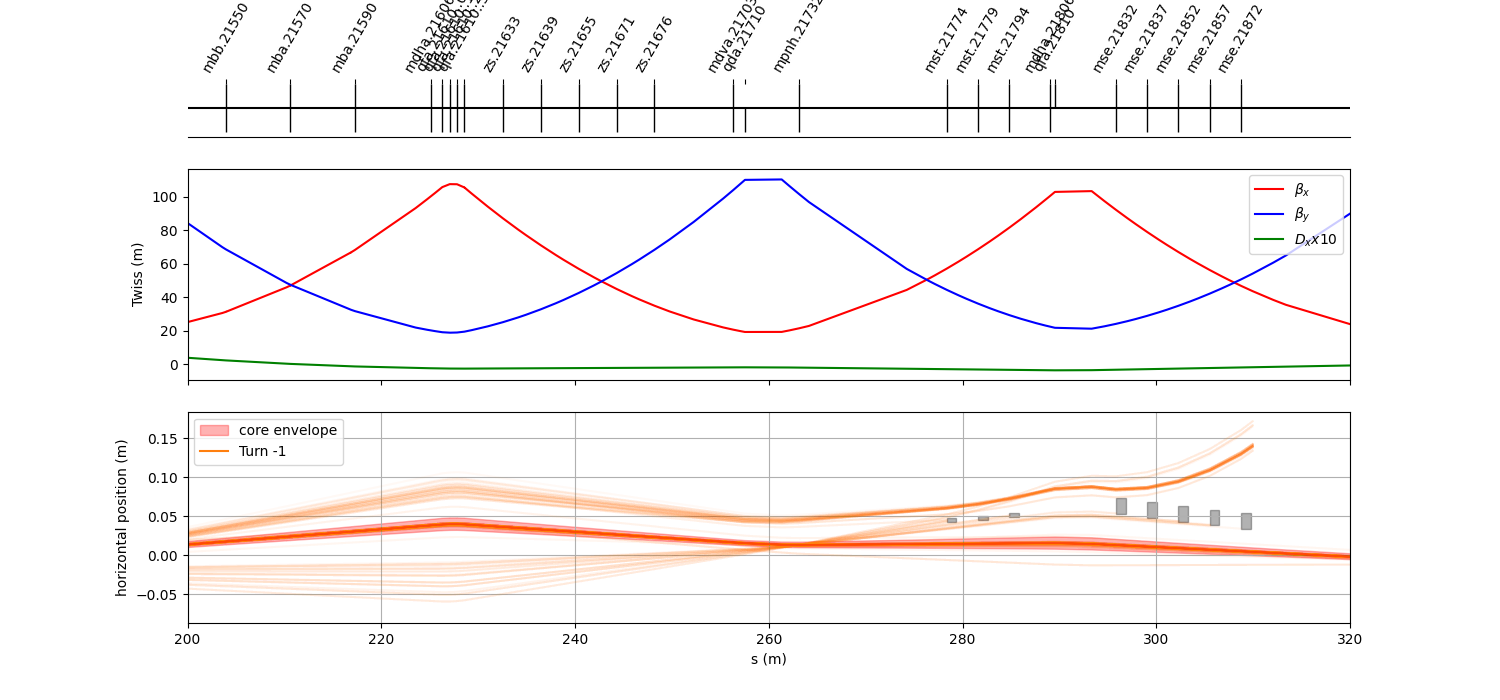

In [78]:
fig = plt.figure(figsize=(15,7))

plot_twiss(fig, tw_lss2, line)
fig.axes[2].grid(True)
fig.axes[2].set_xlim(200, 320)
fig.axes[2].set_xlabel('s (m)')
fig.axes[2].set_ylabel('horizontal position (m)')

# plotting of the envelope
fig.axes[2].plot(tw_lss2.s, tw_lss2.x, 'r-')
fig.axes[2].fill_between(tw_lss2.s, tw_lss2.x-sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), tw_lss2.x+sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), color='r', alpha=0.3, label='core envelope')

for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    fig.axes[2].add_patch(mpl.patches.Rectangle((s, x), 1, thickness, color='k', alpha=0.3))
    
   
   
## PLOTTING TRAJECTORIES   
n_traj = 500

ax = fig.axes[2]
alpha = 10/n_traj
plot_only_lost = False
num_turns = 1

all_trajs = tw_lss2_df.apply(lambda row: row['monitors'].x, axis=1)
all_trajs = np.stack(all_trajs.values)

for ipart in np.random.randint(0, particles._capacity, size=n_traj):
    state = particles.state[ipart]
    if plot_only_lost and state > 0:
        print(f"Skipping particle {ipart} ")
        continue

    particle_id = particles.particle_id[ipart]
    el_lost = particles.at_element[ipart]
    traj = all_trajs[:, particle_id, :]
    # print(f"Particle {ipart} lost at {el_lost} with state {state} and id {particle_id} ")

    if state <= 0:
        # need to recontruct the turns since the particle was last
        s_lost = line.get_table()['s', line.element_names[el_lost]]
        row_lost = tw_lss2_df[abs(tw_lss2_df['s'] - s_lost) < 30e-3].iloc[0]
        i_lost = row_lost['i_monitor']+1

        traj_corr = np.nan * np.ones_like(traj)
        traj_corr[:i_lost, -1] = traj[:i_lost, -1]
        for iturn in range(2, num_turns+1):
            traj_corr[:, -iturn] = np.hstack([traj[:i_lost, -iturn-1], traj[i_lost:, -iturn]])
        traj = traj_corr

    for iturn in range(1, num_turns+1):
        ax.plot(tw_lss2_df['s'], traj[:, -iturn], color=plt.cm.tab10(iturn), alpha=alpha, ls='-') 
for iturn in range(1, num_turns+1):
    ax.plot([], [], color=plt.cm.tab10(iturn), label=f"Turn -{iturn}")
ax.legend()

## phase space at the crystal

Text(0, 0.5, "$x'$ (mrad)")

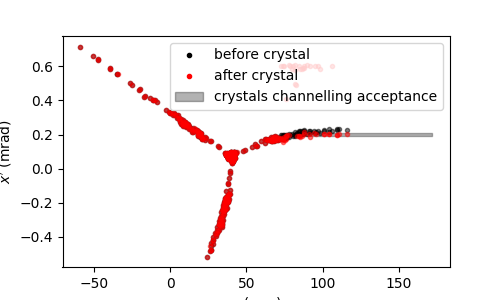

In [72]:
row_before_crystal = tw_lss2_df.loc['extraction.crystal.up']
row_after_crystal = tw_lss2_df.loc['extraction.crystal.dn']

fig, ax = plt.subplots(1, 1, figsize=(5,3))

ax.plot(row_before_crystal['monitors'].x*1e3, row_before_crystal['monitors'].px*1e3, 'k.', alpha = 0.5)
ax.plot(row_after_crystal['monitors'].x*1e3, row_after_crystal['monitors'].px*1e3, 'r.', alpha = 0.5)
ax.plot()

ax.plot([], [], 'k.', label='before crystal')
ax.plot([], [], 'r.', label='after crystal')
ax.fill_between([crystal.jaw*1e3, crystal.jaw*1e3 + crystal.width*1e3], [crystal.tilt*1e3 - 10e-3]*2, [crystal.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
ax.legend()

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")



In [73]:
row = tw_lss2_df.loc['tpst.21760_entry']


ax.plot(row['monitors'].x*1e3, row['monitors'].px*1e3, 'b.', alpha = 0.5, label = 'before TPST')


In [74]:
crystal.critical_angle

In [75]:
tab = line.get_table()

In [76]:
crystal.jaw

np.float64(0.072)